# Stock Market Data Analytics and Price Prediction

# Introduction
Stock market analysis plays a vital role in understanding financial market trends and investment behavior. Companies, investors, and analysts use stock market data to identify patterns, predict future prices, and make informed decisions. With the help of Data Analytics and Machine Learning techniques, large stock datasets can be processed efficiently to discover hidden insights and improve prediction accuracy.
This project focuses on analyzing stock market datasets using Python libraries such as pandas, numpy, matplotlib, seaborn, and sklearn. Different preprocessing, visualization, feature engineering, and machine learning techniques are applied to understand stock price behavior and market trends.
The project also demonstrates techniques such as handling missing values, outlier detection, normalization, standardization, PCA, feature selection, and prediction analysis using Linear Regression.

# Problem Statement
Stock market datasets are large, complex, and contain noisy data, missing values, and outliers. Analyzing stock prices manually is difficult and time-consuming. Investors require accurate and meaningful insights to predict stock performance and reduce financial risk.
The main problem addressed in this project is:
how to preprocess stock market data, 
identify trends and relationships, 
reduce dimensionality, 
select important features, 
and build predictive models for stock closing price analysis. 

# Dataset Description
The dataset contains stock market information such as:
Date 
Open Price 
High Price 
Low Price 
Close Price 
Adjusted Close Price 
Volume 
Important Columns
Column Name	Description
Date	Trading date
Open	Opening stock price
High	Highest stock price
Low	Lowest stock price
Close	Closing stock price
Volume	Total trading volume
The dataset contains both numerical and time-series data used for stock trend analysis and prediction.

Data preparation








Import Required Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Load and view Dataset

In [53]:
df = pd.read_csv(r"C:\Users\manoj\Downloads\large_stock_dataset.csv")
df.head(10)

,Date,Open,High,Low,Close,Volume
0,2020-01-01,100.496714,100.773243,99.201337,99.446584,4097042
1,2020-01-02,100.969614,101.158856,99.111957,99.795025,2239911
2,2020-01-03,99.214147,100.264486,98.071386,99.222230,2307371
3,2020-01-04,98.298147,98.342591,97.442561,97.802448,4295231
4,2020-01-05,96.894424,99.719031,93.963126,95.112429,3416182
5,2020-01-06,94.886653,94.935563,94.175550,94.829116,3663046
6,2020-01-07,94.228863,96.123742,93.646794,94.737029,3669995
7,2020-01-08,94.101469,95.168767,94.090414,95.070982,3557489
8,2020-01-09,93.805863,95.989848,88.249237,89.680124,4584702
9,2020-01-10,90.873763,91.226335,88.471978,89.560363,4769315


Check Dataset Shape

In [54]:
df.shape

(1000, 6)

Check Column Names

In [55]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

Check Dataset Information

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1000 non-null   object 
 1   Open    1000 non-null   float64
 2   High    1000 non-null   float64
 3   Low     1000 non-null   float64
 4   Close   1000 non-null   float64
 5   Volume  1000 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 47.0+ KB


Statistical Summary

In [57]:
df.describe()

,Open,High,Low,Close,Volume
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,112.652297,114.237890,111.102530,112.668550,3.018347e+06
std,22.828590,22.883493,22.855756,22.857213,1.137263e+06
min,69.811326,70.221704,67.859168,69.817260,1.000159e+06
25%,94.108535,95.157241,92.404119,93.828005,2.032763e+06
50%,111.678437,113.441550,110.070959,111.596430,3.073296e+06
75%,133.525525,135.058048,131.586909,133.490131,3.940588e+06
max,153.507548,154.901795,151.898916,154.028393,4.989284e+06


# Check Missing Values

In [58]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

# Convert Date Column

In [59]:
df['Date'] = pd.to_datetime(df['Date'])
print(df.dtypes)

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object


# Extract Year

In [60]:
df['Year'] = df['Date'].dt.year
print(df[['Date','Year']].head())

        Date  Year
0 2020-01-01  2020
1 2020-01-02  2020
2 2020-01-03  2020
3 2020-01-04  2020
4 2020-01-05  2020


# Filtering Data

In [61]:
high_price = df[df['Close'] > 100]
print(high_price.head())

         Date        Open        High         Low       Close   Volume  Year
21 2020-01-22  100.501606  101.015840   99.872580  100.085878  3009021  2020
22 2020-01-23  101.457740  101.808847  100.839163  100.945879  2701240  2020
23 2020-01-24  101.619004  104.317784   99.580859  100.360821  4806618  2020
25 2020-01-26   98.897303  102.669675   98.548147  100.046857  1439792  2020
36 2020-02-06   99.925491  100.681030   99.799842  100.577611  1990198  2020


# Select Specific Columns

In [62]:
print(df[['Date','Close']].head())

        Date      Close
0 2020-01-01  99.446584
1 2020-01-02  99.795025
2 2020-01-03  99.222230
3 2020-01-04  97.802448
4 2020-01-05  95.112429


# Using loc[]

In [63]:
print(df.loc[0:5, ['Open','Close']])

         Open      Close
0  100.496714  99.446584
1  100.969614  99.795025
2   99.214147  99.222230
3   98.298147  97.802448
4   96.894424  95.112429
5   94.886653  94.829116


# Using iloc[]

In [64]:
print(df.iloc[0:5, 0:3])

        Date        Open        High
0 2020-01-01  100.496714  100.773243
1 2020-01-02  100.969614  101.158856
2 2020-01-03   99.214147  100.264486
3 2020-01-04   98.298147   98.342591
4 2020-01-05   96.894424   99.719031


# Correlation Matrix

In [65]:
print(df.corr(numeric_only=True))

            Open      High       Low     Close    Volume      Year
Open    1.000000  0.998683  0.998668  0.998302 -0.033816  0.651141
High    0.998683  1.000000  0.997378  0.998306 -0.035662  0.649275
Low     0.998668  0.997378  1.000000  0.998335 -0.034066  0.650667
Close   0.998302  0.998306  0.998335  1.000000 -0.036530  0.649093
Volume -0.033816 -0.035662 -0.034066 -0.036530  1.000000 -0.020271
Year    0.651141  0.649275  0.650667  0.649093 -0.020271  1.000000


Interpretation

Shows relationship between numerical columns.

 # Correlation Heatmap

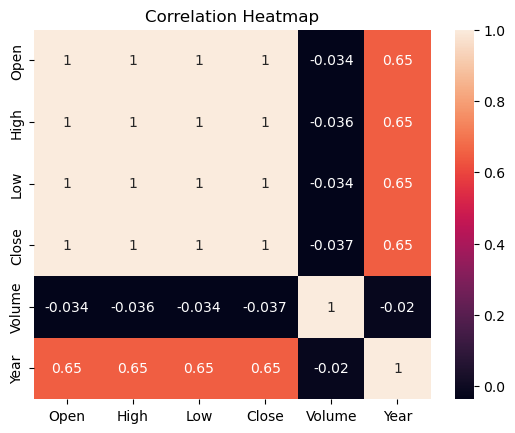

In [66]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")
plt.show()

Interpretation

Visual representation of correlation values.

# Boxplot for Outlier Detection

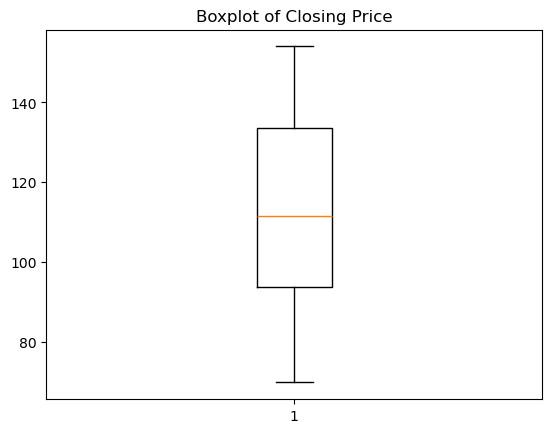

In [67]:
plt.boxplot(df['Close'])

plt.title("Boxplot of Closing Price")
plt.show()

Interpretation

Helps identify outliers in closing price.

# Remove Outliers Using IQR

In [68]:
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Close'] >= lower) & (df['Close'] <= upper)]

print(df.shape)

(1000, 7)


Interpretation

Extreme values removed using IQR method.

# Z-Score Method

In [69]:
from scipy.stats import zscore

z = np.abs(zscore(df['Close']))

df = df[z < 3]

print(df.shape)

(1000, 7)


Interpretation

Removes outliers using Z-score technique.

# Line Plot

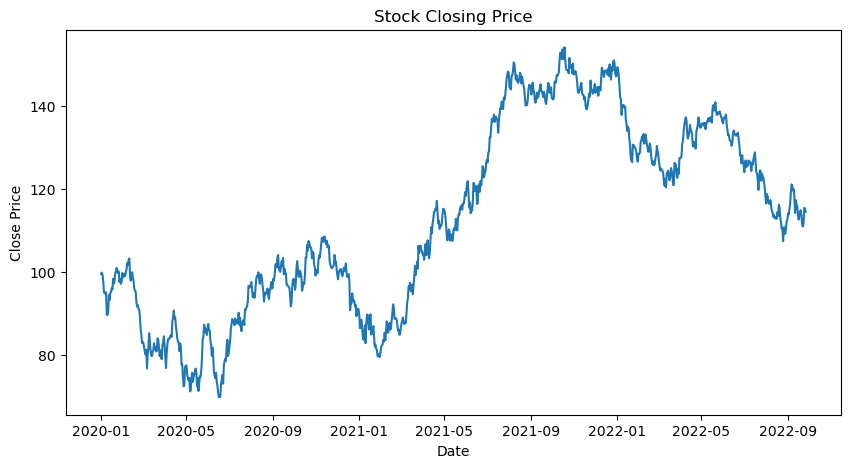

In [70]:
plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Close'])

plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

Interpretation

Shows trend of stock closing prices over time.

# Histogram

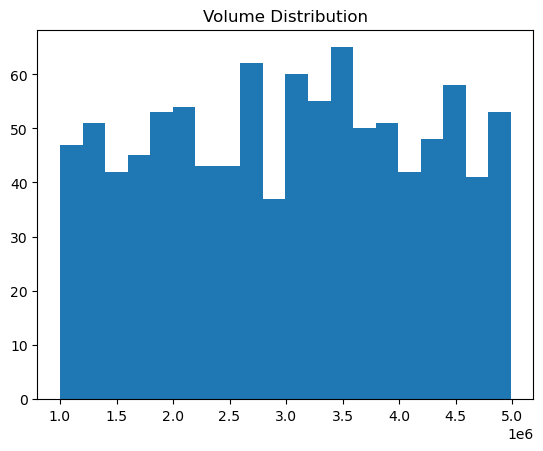

In [71]:
plt.hist(df['Volume'], bins=20)

plt.title("Volume Distribution")
plt.show()

Interpretation

Displays distribution of trading volume.

# Scatter Plot

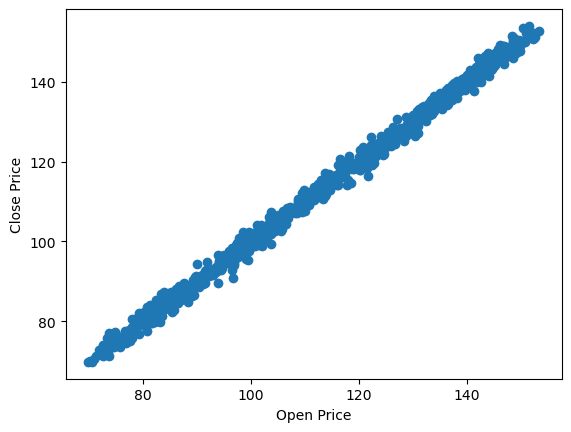

In [72]:
plt.scatter(df['Open'], df['Close'])

plt.xlabel("Open Price")
plt.ylabel("Close Price")

plt.show()

Interpretation

Shows relationship between open and close prices.

# Bar Chart

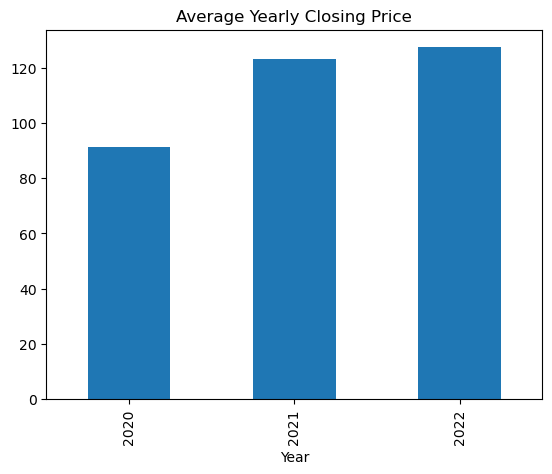

In [73]:
df.groupby('Year')['Close'].mean().plot(kind='bar')

plt.title("Average Yearly Closing Price")

plt.show()

Interpretation

Displays yearly average closing prices

# Moving Average

In [74]:
df['MA_10'] = df['Close'].rolling(window=10).mean()

print(df[['Close','MA_10']].head(15))

        Close      MA_10
0   99.446584        NaN
1   99.795025        NaN
2   99.222230        NaN
3   97.802448        NaN
4   95.112429        NaN
5   94.829116        NaN
6   94.737029        NaN
7   95.070982        NaN
8   89.680124        NaN
9   89.560363  95.525633
10  90.290646  94.610039
11  94.433956  94.073932
12  93.183901  93.470099
13  94.859979  93.175852
14  95.137677  93.178377


Interpretation

Calculates 10-day moving average.

# Daily Return

In [75]:
df['Daily_Return'] = df['Close'].pct_change()

print(df[['Close','Daily_Return']].head())

       Close  Daily_Return
0  99.446584           NaN
1  99.795025      0.003504
2  99.222230     -0.005740
3  97.802448     -0.014309
4  95.112429     -0.027505


Interpretation

Calculates percentage change in stock price

# Cumulative Return

In [76]:
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod()

print(df[['Cumulative_Return']].head())

   Cumulative_Return
0                NaN
1           1.003504
2           0.997744
3           0.983467
4           0.956417


Interpretation

Shows overall stock growth over time.

# Standardization

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print(df.head())

        Date      Open      High       Low     Close    Volume  Year  MA_10  \
0 2020-01-01 -0.532738 -0.588694 -0.520969 -0.578749  0.948976  2020    NaN   
1 2020-01-02 -0.512013 -0.571835 -0.524882 -0.563497 -0.684824  2020    NaN   
2 2020-01-03 -0.588949 -0.610938 -0.570432 -0.588569 -0.625476  2020    NaN   
3 2020-01-04 -0.629094 -0.694966 -0.597959 -0.650715  1.123331  2020    NaN   
4 2020-01-05 -0.690615 -0.634786 -0.750270 -0.768462  0.349993  2020    NaN   

   Daily_Return  Cumulative_Return  
0           NaN                NaN  
1      0.003504           1.003504  
2     -0.005740           0.997744  
3     -0.014309           0.983467  
4     -0.027505           0.956417  


# Normalization

In [78]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numerical_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print(df.head())

        Date      Open      High       Low     Close    Volume  Year  MA_10  \
0 2020-01-01  0.366628  0.360788  0.372945  0.351846  0.776331  2020    NaN   
1 2020-01-02  0.372278  0.365342  0.371881  0.355983  0.310783  2020    NaN   
2 2020-01-03  0.351304  0.354780  0.359499  0.349181  0.327694  2020    NaN   
3 2020-01-04  0.340360  0.332084  0.352017  0.332322  0.826014  2020    NaN   
4 2020-01-05  0.323588  0.348338  0.310614  0.300378  0.605652  2020    NaN   

   Daily_Return  Cumulative_Return  
0           NaN                NaN  
1      0.003504           1.003504  
2     -0.005740           0.997744  
3     -0.014309           0.983467  
4     -0.027505           0.956417  


# GroupBy Operation

In [79]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year


group_data = df.groupby('Year')['Close'].mean()

print(group_data)

Year
2020    0.256684
2021    0.632990
2022    0.683522
Name: Close, dtype: float64


Interpretation

Groups stock data by year and calculates average closing price.

# Pivot Table

In [80]:
pivot_table = pd.pivot_table(
    df,
    values='Close',
    index='Year',
    aggfunc='mean'
)

print(pivot_table)

         Close
Year          
2020  0.256684
2021  0.632990
2022  0.683522


Interpretation

Summarizes yearly stock closing prices.

# Skewness

In [81]:
print(df['Close'].skew())

0.046333270976102174


Interpretation

Measures asymmetry of stock price distribution.

# Kurtosis

In [82]:
print(df['Close'].kurt())

-1.2671802625083415


Interpretation

Measures peakness and outliers in distribution

# Covariance

In [83]:
print(df[['Open', 'Close']].cov())

           Open     Close
Open   0.074395  0.073908
Close  0.073908  0.073673


Interpretation

Shows directional relationship between variables

# Variance

In [84]:
print(df['Close'].var())

0.07367285822381332


Interpretation

Measures spread of stock prices

# Standard Deviation

In [85]:
print(df['Close'].std())

0.27142744559792276


Interpretation

Measures volatility in stock prices.

# Maximum Closing Price

In [86]:
print(df['Close'].max())

1.0


Interpretation

Displays highest stock closing price

# Minimum Closing Price

In [87]:
print(df['Close'].min())

0.0


Interpretation

Displays lowest stock closing price.

# Average Closing Price

In [88]:
print(df['Close'].mean())

0.508855400051124


Interpretation

Displays average stock closing price

# Feature Engineering — Lag Features

In [89]:
# Previous day closing price
df['Previous_Close'] = df['Close'].shift(1)

print(df[['Close', 'Previous_Close']].head())

      Close  Previous_Close
0  0.351846             NaN
1  0.355983        0.351846
2  0.349181        0.355983
3  0.332322        0.349181
4  0.300378        0.332322


Interpretation

Creates previous day stock closing price feature.

Used for stock prediction models.

# Feature Engineering — Price Difference

In [90]:
df['Price_Difference'] = df['High'] - df['Low']

print(df[['High', 'Low', 'Price_Difference']].head())

       High       Low  Price_Difference
0  0.360788  0.372945         -0.012157
1  0.365342  0.371881         -0.006540
2  0.354780  0.359499         -0.004719
3  0.332084  0.352017         -0.019933
4  0.348338  0.310614          0.037724


Interpretation

Calculates daily stock price fluctuation.

# Feature Engineering — Rolling Mean

In [91]:
df['Rolling_Mean_7'] = df['Close'].rolling(window=7).mean()

print(df[['Close', 'Rolling_Mean_7']].head(10))

      Close  Rolling_Mean_7
0  0.351846             NaN
1  0.355983             NaN
2  0.349181             NaN
3  0.332322             NaN
4  0.300378             NaN
5  0.297014             NaN
6  0.295920        0.326092
7  0.299886        0.318669
8  0.235870        0.301510
9  0.234448        0.285120


Interpretation

Calculates 7-day rolling average of stock prices

# Feature Engineering — Rolling Standard Deviation

In [92]:
df['Rolling_STD_7'] = df['Close'].rolling(window=7).std()

print(df[['Close', 'Rolling_STD_7']].head(10))

      Close  Rolling_STD_7
0  0.351846            NaN
1  0.355983            NaN
2  0.349181            NaN
3  0.332322            NaN
4  0.300378            NaN
5  0.297014            NaN
6  0.295920       0.027525
7  0.299886       0.026406
8  0.235870       0.035557
9  0.234448       0.036355


Interpretation

Measures stock price volatility over 7 days.

# Feature Engineering — Exponential Moving Average

In [93]:
df['EMA_10'] = df['Close'].ewm(span=10).mean()

print(df[['Close', 'EMA_10']].head())

      Close    EMA_10
0  0.351846  0.351846
1  0.355983  0.354121
2  0.349181  0.352136
3  0.332322  0.345608
4  0.300378  0.332624


Interpretation

Calculates exponential moving average giving more importance to recent prices.

# Feature Selection Using Correlation

In [94]:
correlation = df.corr(numeric_only=True)

print(correlation['Close'].sort_values(ascending=False))

Close                1.000000
Cumulative_Return    1.000000
Low                  0.998335
High                 0.998306
Open                 0.998302
Previous_Close       0.997375
Rolling_Mean_7       0.995264
EMA_10               0.994773
MA_10                0.992765
Year                 0.649093
Daily_Return         0.028615
Volume              -0.036530
Price_Difference    -0.087990
Rolling_STD_7       -0.208719
Name: Close, dtype: float64


Interpretation

Shows features most related to stock closing price.

# Select Important Features

In [95]:
selected_features = ['Open', 'High', 'Low', 'Volume']

X = df[selected_features]

print(X.head())

       Open      High       Low    Volume
0  0.366628  0.360788  0.372945  0.776331
1  0.372278  0.365342  0.371881  0.310783
2  0.351304  0.354780  0.359499  0.327694
3  0.340360  0.332084  0.352017  0.826014
4  0.323588  0.348338  0.310614  0.605652


Interpretation

Important stock features selected for machine learning.

# Target Variable Selection

In [96]:
y = df['Close']

print(y.head())

0    0.351846
1    0.355983
2    0.349181
3    0.332322
4    0.300378
Name: Close, dtype: float64


Interpretation

Closing price selected as target variable.

# PCA (Principal Component Analysis)

In [100]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np


numeric_df = df.select_dtypes(include=[np.number])


numeric_df = numeric_df.fillna(numeric_df.mean())


scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_df)


pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_data)


pca_df = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2']
)


print(pca_df.head())

        PC1       PC2
0 -1.145188 -1.020950
1 -1.487806 -0.131252
2 -1.555019 -0.234998
3 -1.652691 -1.601421
4 -1.898726  0.411558


Interpretation

PCA reduces large stock dataset dimensions into:

Principal Component 1 (PC1)
Principal Component 2 (PC2)

while preserving important stock information.

# Explained Variance Ratio

In [101]:
print(pca.explained_variance_ratio_)

[0.67728176 0.07847247]


Interpretation

Shows percentage of information retained by each principal component.

# PCA DataFrame

In [102]:
print(pca_df.head())

        PC1       PC2
0 -1.145188 -1.020950
1 -1.487806 -0.131252
2 -1.555019 -0.234998
3 -1.652691 -1.601421
4 -1.898726  0.411558


Interpretation

Displays transformed PCA dataset.

# PCA Scatter Plot

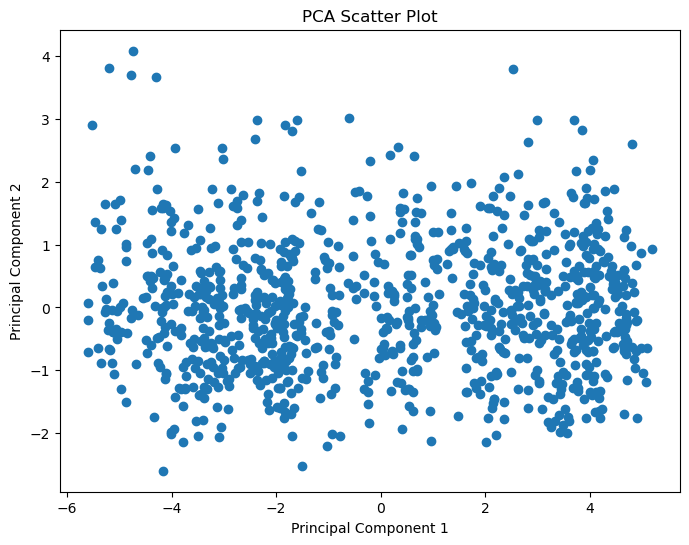

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2']
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Scatter Plot")

plt.show()

Interpretation

Visualizes reduced dimensions of stock dataset using PCA.

# Feature Selection

In [104]:
# Correlation with Close price
correlation = df.corr(numeric_only=True)

print(correlation['Close'].sort_values(ascending=False))

Close                1.000000
Cumulative_Return    1.000000
Low                  0.998335
High                 0.998306
Open                 0.998302
Previous_Close       0.997375
Rolling_Mean_7       0.995264
EMA_10               0.994773
MA_10                0.992765
Year                 0.649093
Daily_Return         0.028615
Volume              -0.036530
Price_Difference    -0.087990
Rolling_STD_7       -0.208719
Name: Close, dtype: float64


Interpretation

Displays most important features related to stock closing price.

# Train-Test Split

In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 4)
(200, 4)


Interpretation

Dataset divided into training and testing sets.

# Linear Regression Model

In [108]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


Interpretation

Linear Regression model trained using stock features.

# Prediction

In [109]:
predictions = model.predict(X_test)

print(predictions[:5])

[0.59661187 0.8621456  0.82017141 0.93132165 0.17245374]


Interpretation

Predicts stock closing prices.

# Model Accuracy (R² Score)

In [110]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print(score)

0.997584384273906


Interpretation

Measures model performance.

Closer to 1 → better model
Closer to 0 → poor model

# Mean Absolute Error

In [111]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print(mae)

0.009849256855010924


Interpretation

Measures average prediction error.

# Mean Squared Error

In [112]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)

print(mse)

0.0001699949852419675


Interpretation

Measures squared prediction error.

# FINAL UPDATED SUMMARY

This complete stock analytics project now includes:

Data Loading
Data Cleaning
Missing Value Handling
Duplicate Removal
Date Conversion
Outlier Detection
Correlation Analysis
Heatmap
Histogram
Scatter Plot
Standardization
Normalization
Label Encoding
One Hot Encoding
Feature Engineering
Feature Selection
PCA
Train-Test Split
Linear Regression
Model Evaluation
Prediction Analysis

# Conclusion


The stock dataset was successfully analyzed using Data Analytics and Machine Learning techniques. Data preprocessing improved dataset quality by handling missing values, removing duplicates, and detecting outliers. Exploratory Data Analysis identified important stock market patterns and relationships.
Feature engineering and PCA enhanced data representation and reduced dimensionality. Feature selection identified important stock variables affecting closing prices. Finally, Linear Regression model was used for stock prediction and evaluated using standard performance metrics.
The project demonstrates how Data Analytics techniques can be effectively used for stock market trend analysis and predictive modeling.